Импорты

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor,KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from skopt import BayesSearchCV
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif,mutual_info_regression
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import csv
from sklearn.linear_model import LogisticRegression

## Загрузка данных

In [ ]:
df = pd.read_excel('data/data.xlsx').drop(columns='Unnamed: 0')
target = 'IC50_classification'
report_name = 'IC50_classification'

Создадим признак для крассификации 

In [ ]:
print(f'Значение медианы для IC50, mM {df['IC50, mM'].median():.3f}')
df['IC50_classification'] = 0
IC50_median = df['IC50, mM'].median()
df.loc[df['IC50, mM']>IC50_median,'IC50_classification']=1


Значение медианы для IC50, mM 46.585


/tmp/ipykernel_221743/2236037398.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['IC50_classification'] = 0


Создадим списки пустых колонок и колонок, которые мы не будем масштабировать (с 0 и 1).

In [ ]:
def show_nullls(df, tolerance):
    #Ищем колонки, где есть процент значений с большим числом 0
    print('='*60)
    print('поиск доли нулевых значений')
    print(f'Пороговое значение равно {tolerance}')
    empty_cols = []
    for col in df.columns:
        zeroes=100*len(df.loc[df[col] == 0])/len(df) 
        if zeroes>=tolerance:
            #print(f'В колонке {col} доля нулей  {(zeroes):.2f} %.')
            empty_cols.append(col)
    print('='*60)
    print(f'Разреженный колонок {len(empty_cols)}.')
    return empty_cols

def find_binary_columns(df):
    #Ищем колонки где значения строго 1 или 2
    binary_columns = []
    for col in df.columns:
        if len(df.loc[df[col]==1])+(len(df.loc[df[col]==0]))==len(df) and df[col].isna().sum()==0 and len(df[col].value_counts())==2:
            binary_columns.append(col)
    print(f'колонок со значениями 0 и 1: {len(binary_columns)}')
    return binary_columns


def find_cols_with_outliers(df,tolerance):
    print('='*60)
    print(f'Признаки, где доля выбросов более {tolerance}%.')
    outliers_list = []
    for col in df.columns:
        series = df[col].dropna()
        if len(df[col].value_counts())==2:
            continue

        series = df[col].dropna()
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Обнаружение выбросов
        mask = (series < lower_bound) | (series > upper_bound)
        outliers_qty = mask.sum()
        outliers_prcnt = 100 * outliers_qty / len(series)
        if outliers_prcnt>tolerance:
            outliers_list.append(col)
            print(f'В колонке {col} есть {outliers_prcnt:.1f} % возможных выбросов')
    print('='*60)
    return outliers_list

def corr_feature(df, min_corr_value):
    # Корреляция между признаками
    print('='*60)
    print('Корреляция между признаками')
    targets = ['CC50, mM', 'IC50_classification', 'CC50_classification','IC50, mM', 'SI', 'SI_classification']
    X = df[[col for col in df.columns if col not in targets]]
    cor_list = []
    total_list_to_delete = []
    for col in X.columns:
        #print(f'Поиск для {col}')
        corr_target = df.corr(numeric_only=True)[col].drop(col)
        high_corr = corr_target[(corr_target >= min_corr_value) | (corr_target <= -min_corr_value)]
        if len(high_corr) > 0:
            cor_target_dict = {col: list(high_corr.index)}
            cor_list.append(cor_target_dict)
            total_list_to_delete.append(list(high_corr.index))
    total_list_to_delete = set(sum(total_list_to_delete, []))
    print(f'Колонок с возможной корреляцией: {len(total_list_to_delete)}')
    print('='*60)
    return cor_list,total_list_to_delete





In [ ]:
#Ищем колонки, где есть процент значений с большим числом 0
empty_columns=show_nullls(df,99)
#Ищем колонки где значения строго 1 или 2
binary_columns =find_binary_columns(df)
#Выбросы
tolerance = 20
outliers_list= find_cols_with_outliers(df,tolerance)
#корреляция признаков
_,corr_feature_list=corr_feature(df, 0.95)



поиск доли нулевых значений
Пороговое значение равно 99
Разреженный колонок 33.
колонок со значениями 0 и 1: 31
Признаки, где доля выбросов более 20%.
В колонке Ipc есть 21.8 % возможных выбросов
В колонке PEOE_VSA4 есть 20.5 % возможных выбросов
В колонке VSA_EState10 есть 25.0 % возможных выбросов
В колонке VSA_EState9 есть 24.5 % возможных выбросов
В колонке fr_Al_OH есть 24.3 % возможных выбросов
В колонке fr_allylic_oxid есть 20.9 % возможных выбросов
В колонке fr_amide есть 24.3 % возможных выбросов
В колонке fr_aniline есть 22.2 % возможных выбросов
Корреляция между признаками
Колонок с возможной корреляцией: 47


## Целевая пременная
### IC50_classification

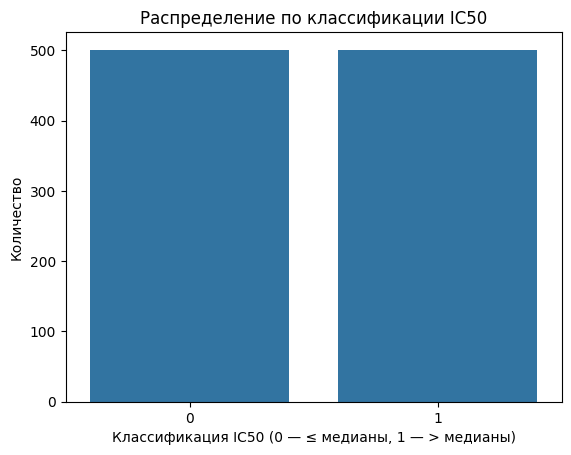

In [ ]:
sns.countplot(data=df, x=target)
plt.title('Распределение по классификации IC50')
plt.xlabel('Классификация IC50 (0 — ≤ медианы, 1 — > медианы)')
plt.ylabel('Количество')
plt.show()

Распределние сильно скошено.

## Оценка важности признаков с помощью алгоритмов машинного обучения
### Регрессия

Поиск для IC50_classification.


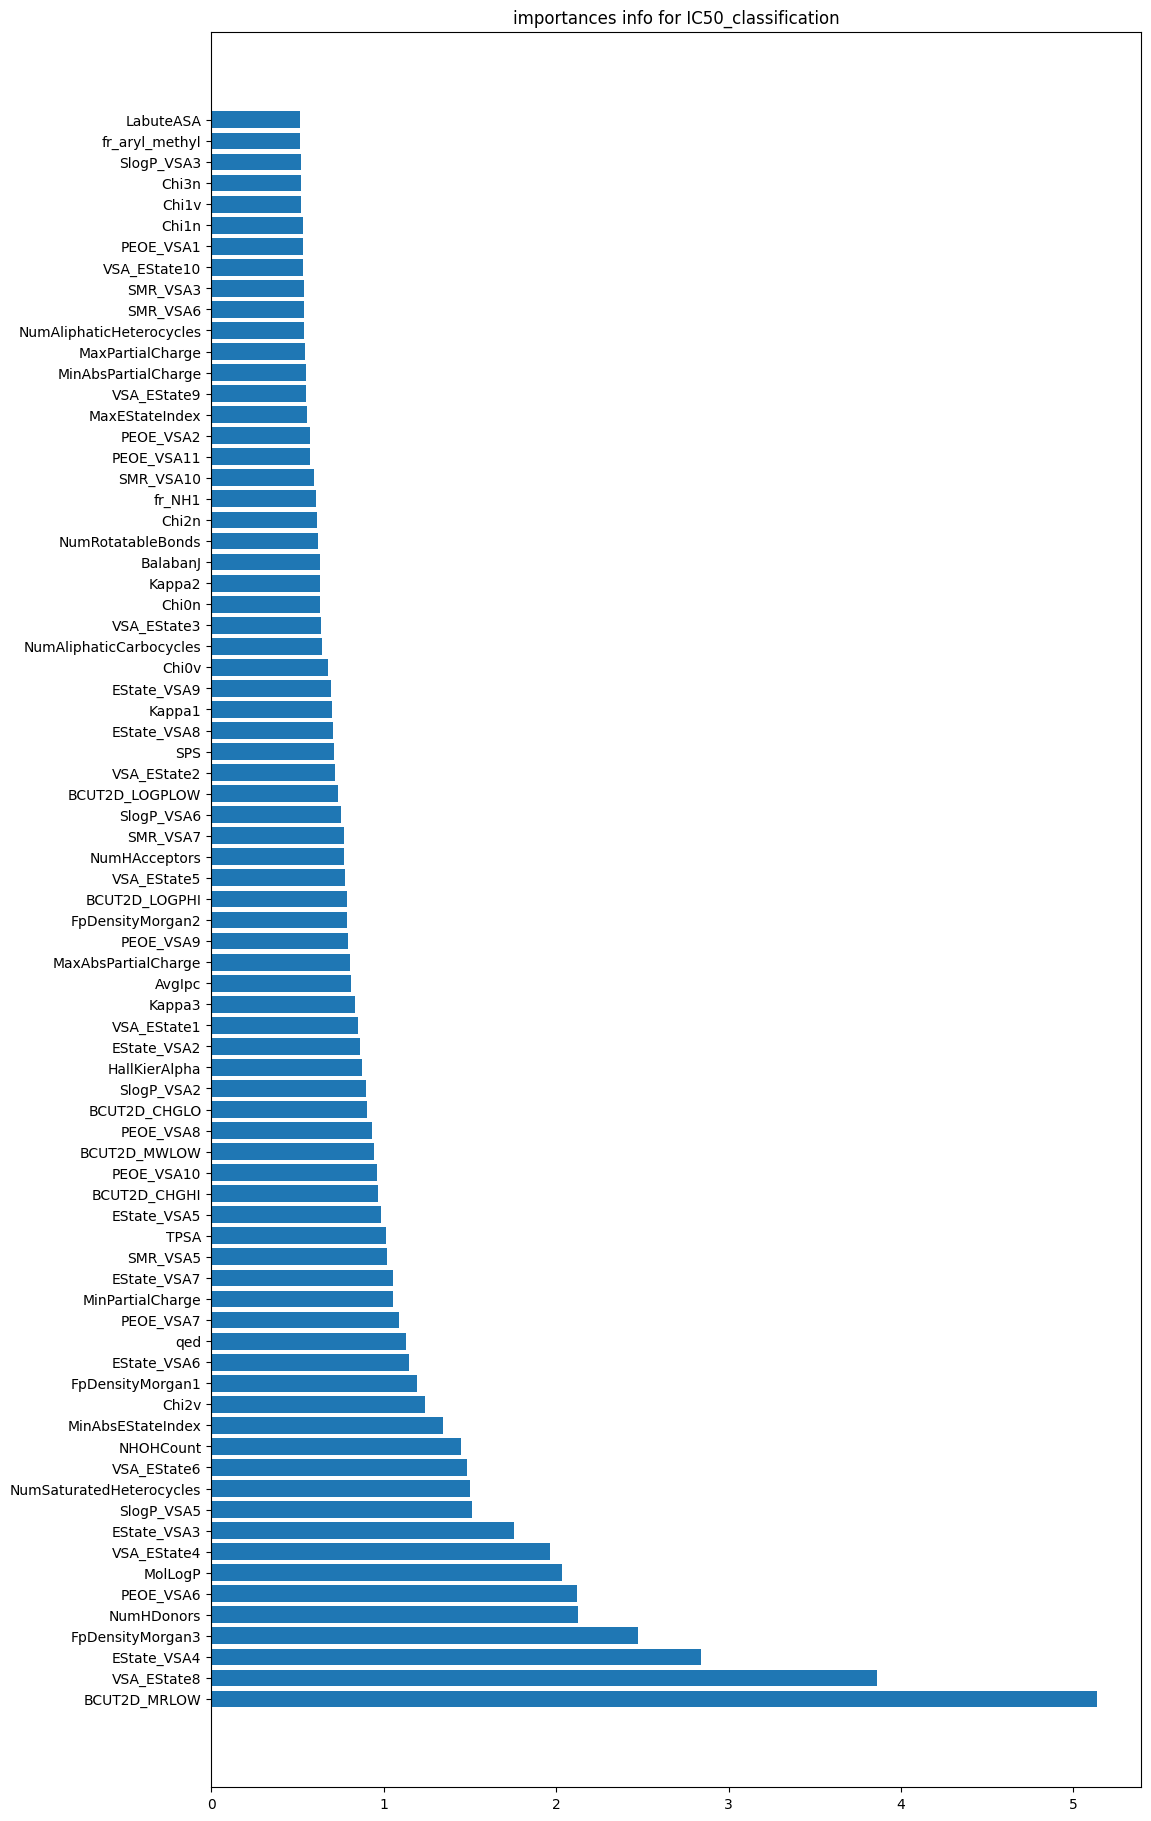

In [ ]:
def catboost_clas_features(df, target,need_plot):
    print(f'Поиск для {target}.')
    targets = ['CC50, mM','IC50_classification','CC50_classification','IC50, mM','SI','SI_classification']
    X = df.copy()[[col for col in df.columns if col not in targets]]
    y = df[target]


    model = CatBoostClassifier(verbose=0, random_seed=42)
    model.fit(X, y)


    # Посмотрим на feature importance с помощью встроенного метода
    importances = model.get_feature_importance(prettified=True)
    importances = importances[importances['Importances']>=0.5]

    if need_plot:
        plt.figure(figsize=(12, max(6, len(importances) * 0.3)))
        plt.barh(importances['Feature Id'], importances['Importances'])
        plt.title(f"importances info for {target}")
        plt.show()

    return list(importances['Feature Id'])

classification_features_dict = {}
classification_features_dict[target]=catboost_clas_features(df, target,True)

Мы изучили датасет и на основании созданных списков переменных можем выкинуть все признаки которые мы считаем невалидными, с высокой внутренней корреляцией, пустые колонки. Для колонок с числовыми признаками, применем масштабирование и метод главных компонент. 

За основу списка признаков мы возьмем только признаки которым CatBoost присвоил важность выше 0.5.

Напишем класс, который на вход принимает список моделей, которые мы будем обучать, препроцессинг им метрику. Если указан параметр 'r2', класс будет работать врежиме оценки регрессии по показателям  r2, rmse и mae.

In [ ]:
class ModelFinderGridCV():
    def __init__(self, 
                 models_dict,
                 model_scoring,
                 preprocessing):
        self.models_dict = models_dict
        self.model_scoring = model_scoring
        self.preprocessing = preprocessing
        self.best_model_name = None
        self.best_estimator_ = None
        self.best_params_ = None
        self.best_score = -float("inf")
        self.best_params = {}
        self.model_leader_board = []
        self.best_score_name = 'best_score_' + self.model_scoring

    def fit(self, X_train, y_train):
        
        for name, (model, params) in self.models_dict.items():
            print(f'Обучение {model}.')
            steps = []
            if self.preprocessing is not None:
                steps.append(("preprocessing", self.preprocessing ))
            steps.append(('model',model))

            full_pipeline = Pipeline(steps)

            # Оптимизация гиперпараметров
            gridsearch = GridSearchCV(
                estimator=full_pipeline,
                param_grid=params,
                cv=5,
                scoring=self.model_scoring,
                )

                    # Обучение модели
            gridsearch.fit(X_train, y_train)
            self.best_score_name = 'best_score_' + self.model_scoring
            result = {'model_name':name, 
                                    self.best_score_name :gridsearch.best_score_ ,
                                    'best_params':gridsearch.best_params_
                                    }
            self.model_leader_board.append(result)

            if gridsearch.best_score_ > self.best_score :
                self.best_score  = gridsearch.best_score_
                self.best_model_name = name
                self.best_params_ = gridsearch.best_params_
                self.best_estimator_ = gridsearch.best_estimator_

            print(f"{name} - {self.model_scoring}: {gridsearch.best_score_:.4f}")


    def predict(self, X):
        if self.best_estimator_ is None:
            return "Нет обученной модели"
        return self.best_estimator_.predict(X)
    
    def build_scoreboard(self):
        return pd.DataFrame(self.model_leader_board).sort_values(by = self.best_score_name, ascending=False).reset_index(drop=True)
            
    def model_self_test(self, X_test, y_test):
        y_pred = self.best_estimator_.predict(X_test)
        if self.model_scoring == 'r2':
            return {
                "best_model_name": self.best_model_name,
                "r2": r2_score(y_test, y_pred),
                "rmse": mean_squared_error(y_test, y_pred),
                "mae": mean_absolute_error(y_test, y_pred)
            }
        elif  self.model_scoring == 'accuracy':
            return {
            'accuracy':accuracy_score(y_test, y_pred),
            'precision':precision_score(y_test, y_pred),
            'recall':recall_score(y_test, y_pred),
            'f1':f1_score(y_test, y_pred),
            }


Список моделей

In [ ]:
models = {
    "LogisticRegression": (
        LogisticRegression(),
        {
            'preprocessing__num__pca__n_components': [5, 10, 20],
            'model__fit_intercept': [True, False],
        }
    ),    
    "DecisionTree": (
        DecisionTreeClassifier(random_state=42),
        {
            'preprocessing__num__pca__n_components': [5, 10, 20],

            'model__max_depth': [3, 5, 10, 15],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 2, 4]
        }
    ),

    "KNN": (
        KNeighborsClassifier(),
        {
            'preprocessing__num__pca__n_components': [5, 10, 20],

            'model__n_neighbors': [3, 5, 10, 15],
            'model__weights': ['uniform', 'distance'],
            'model__p': [1, 2]
        }
    ),
        "RandomForest": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            'preprocessing__num__pca__n_components': [5, 10, 20],

            'model__n_estimators': [100, 200],
            'model__max_depth': [5, 10, 15],
            'model__min_samples_split': [2, 5],
            'model__min_samples_leaf': [1, 2],
            'model__max_features': ['sqrt', 'log2']
        }
    ),
    "CatBoost": (
        CatBoostClassifier(
            verbose=0,
            random_state=42
        ),
        {
            'preprocessing__num__pca__n_components': [5, 10, 20],
            'model__depth': [8,10,12],
        }
    ),
}


In [ ]:

#Ищем колонки, где есть процент значений с большим числом 0
empty_columns=show_nullls(df,99)
#Ищем колонки где значения строго 1 или 2
binary_features =find_binary_columns(df)
#Выбросы
tolerance = 20
outliers_list= find_cols_with_outliers(df,tolerance)
#корреляция признаков
_,corr_feature_list=corr_feature(df, 0.95)


selected_features = classification_features_dict[target]
#Убираем лишние признаки

problem_columns = set(empty_columns + binary_columns + outliers_list)


X = df.copy().drop(columns=(target))[selected_features]
y = df[target]

selected_features = [x for x in selected_features if x not in problem_columns]
#бинарные и числовые признаки
numeral_features = [col for col in X.columns if col not in binary_features]

numeric_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

preprocessor = ColumnTransformer([
    ('num', numeric_preprocessor, numeral_features)
], remainder='drop')

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# finder
best_model_finder = ModelFinderGridCV(
    models_dict=models,
    model_scoring='accuracy',
    preprocessing=preprocessor,
)

best_model_finder.fit(X_train, y_train)

print("Таблица результатов")

print(best_model_finder.build_scoreboard())

print("Лучшая модель:")
print(best_model_finder.best_model_name)
print(best_model_finder.best_params_)

print("Оценка на тестовой выбоке:")
print(best_model_finder.model_self_test(X_test, y_test))


поиск доли нулевых значений
Пороговое значение равно 99
Разреженный колонок 33.
колонок со значениями 0 и 1: 31
Признаки, где доля выбросов более 20%.
В колонке Ipc есть 21.8 % возможных выбросов
В колонке PEOE_VSA4 есть 20.5 % возможных выбросов
В колонке VSA_EState10 есть 25.0 % возможных выбросов
В колонке VSA_EState9 есть 24.5 % возможных выбросов
В колонке fr_Al_OH есть 24.3 % возможных выбросов
В колонке fr_allylic_oxid есть 20.9 % возможных выбросов
В колонке fr_amide есть 24.3 % возможных выбросов
В колонке fr_aniline есть 22.2 % возможных выбросов
Корреляция между признаками
Колонок с возможной корреляцией: 47
Обучение LogisticRegression().
LogisticRegression - accuracy: 0.6825
Обучение DecisionTreeClassifier(random_state=42).
DecisionTree - accuracy: 0.6725
Обучение KNeighborsClassifier().
KNN - accuracy: 0.7250
Обучение RandomForestClassifier(n_jobs=-1, random_state=42).
RandomForest - accuracy: 0.7175
Обучение CatBoostClassifier(random_state=42, verbose=0).
CatBoost - accur

In [ ]:
best_model_finder.build_scoreboard().to_csv('report_csv/'+report_name+'.csv')
best_model_report = best_model_finder.model_self_test(X_test, y_test)

with open('report_csv/'+report_name+'_best_model.csv', 'w') as csv_file:  
    writer = csv.writer(csv_file)
    for key, value in best_model_report.items():
       writer.writerow([key, value])

KNN — лучшая модель по результатам кросс‑валидации (точность 0,7250), на тестовой выборке - 0,712. 